# Analisis Perbandingan Performa Klasifikasi Jaringan Saraf Tiruan (MLP) pada Dataset Iris

---

| | |
|---|---|
| **Nama** | Sistra Amanda Sinaga |
| **NIM** | 4222301011 |
| **Kelas** | Robotika A |

---

### Panduan Singkat:
1. **Apa itu MLP?** Jaringan Saraf Tiruan yang meniru cara kerja otak manusia untuk mempelajari pola data.
2. **Apa itu Fungsi Aktivasi?** "Saklar" atau gerbang logika di dalam jaringan saraf yang menentukan apakah suatu informasi penting harus diteruskan atau tidak. Di sini kita menguji 3 saklar: **Sigmoid**, **Tanh**, dan **ReLU**.
3. **Apa itu Dataset Iris?** Data karakteristik bunga Iris (panjang/lebar kelopak dan mahkota) untuk menebak 3 spesies bunga Iris.


#### Langkah 1: Mengimpor Library dan Mempersiapkan Data

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#### 2. Memuat dan Membersihkan Dataset
Penjelasan

Dataset Iris dimuat dari file CSV. Jika terdapat kolom yang tidak diperlukan seperti ID, kolom tersebut dihapus. Selain itu dilakukan pembersihan nama spesies agar lebih mudah diproses.

In [102]:
# =====================================================================
# LANGKAH 1: MEMUAT & MEMBERSIHKAN DATASET
# =====================================================================
# Memuat file
df = pd.read_csv('Iris.csv')

# Menghapus kolom Id jika ada
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Membersihkan teks 'Iris-' di awal agar hanya menyisakan 'setosa', dll.
df['Species'] = df['Species'].str.replace('Iris-', '', case=False)

print("✅ Langkah 1: Dataset berhasil dimuat dan teks 'Iris-' telah dibersihkan!")
print(df.head(), "\n")

✅ Langkah 1: Dataset berhasil dimuat dan teks 'Iris-' telah dibersihkan!
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm Species
0            5.1           3.5            1.4           0.2  setosa
1            4.9           3.0            1.4           0.2  setosa
2            4.7           3.2            1.3           0.2  setosa
3            4.6           3.1            1.5           0.2  setosa
4            5.0           3.6            1.4           0.2  setosa 



#### 3. Eksplorasi dan Visualisasi Dataset Iris
Penjelasan

Tahap ini bertujuan untuk melihat distribusi setiap fitur pada dataset Iris sehingga karakteristik masing-masing spesies dapat diamati secara visual.

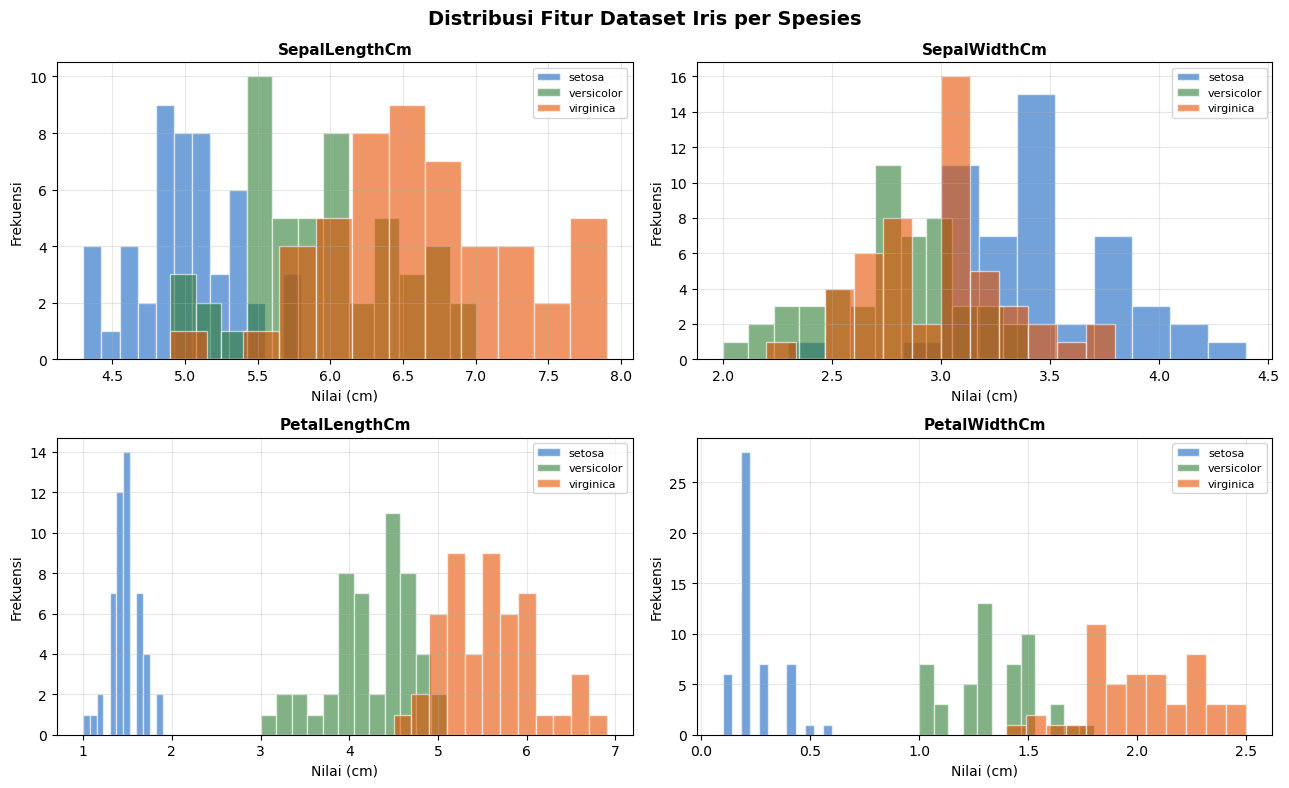

✅ Langkah 2: Grafik Distribusi Fitur Berhasil Ditampilkan!



In [103]:
# =====================================================================
# LANGKAH 2: VISUALISASI DISTRIBUSI FITUR (Eksplorasi Data)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribusi Fitur Dataset Iris per Spesies', fontsize=14, fontweight='bold')

fitur = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
warna = {'setosa': '#1565C0', 'versicolor': '#2E7D32', 'virginica': '#E65100'}
species = df['Species'].unique()

for ax, col in zip(axes.flatten(), fitur):
    for sp in species:
        data = df[df['Species'] == sp][col]
        ax.hist(data, bins=12, alpha=0.6, label=sp, color=warna[sp], edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai (cm)')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Langkah 2: Grafik Distribusi Fitur Berhasil Ditampilkan!\n")

#### 4. Preprocessing Data
Penjelasan

Data kategorikal diubah menjadi numerik menggunakan Label Encoder. Selanjutnya data dibagi menjadi data latih dan data uji, kemudian dilakukan standarisasi agar seluruh fitur berada pada skala yang sama.

In [104]:
# =====================================================================
# LANGKAH 3: PREPROCESSING DATA (Ubah ke Angka & Standarisasi)
# =====================================================================
# Mengubah teks spesies menjadi angka 0, 1, 2
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Memisahkan fitur dan target
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = df['Species'].values

# Split data: 70% Training, 30% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standarisasi skala data numerik (Sangat penting untuk Jaringan Saraf / MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Langkah 3: Preprocessing selesai! Data latih: {X_train_scaled.shape[0]} sampel, Data uji: {X_test_scaled.shape[0]} sampel.\n")

✅ Langkah 3: Preprocessing selesai! Data latih: 105 sampel, Data uji: 45 sampel.



#### 5. Pelatihan dan Pengujian Model Menggunakan Fungsi Aktivasi Sigmoid
Penjelasan

Pada tahap ini model MLP dilatih menggunakan fungsi aktivasi Sigmoid. Setelah proses pelatihan selesai, model dievaluasi menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.

In [105]:
# =====================================================================
# LANGKAH 4: PELATIHAN & PENGUJIAN MODEL SECARA MANDIRI
# =====================================================================

print("=== [PENGUJIAN MODEL 1: SIGMOID] ===")
mlp_sigmoid = MLPClassifier(hidden_layer_sizes=(10, 10), activation='logistic', max_iter=2000, random_state=42, learning_rate_init=0.01)
mlp_sigmoid.fit(X_train_scaled, y_train)
y_pred_sigmoid = mlp_sigmoid.predict(X_test_scaled)
acc_sigmoid = accuracy_score(y_test, y_pred_sigmoid)
prec_sigmoid = precision_score(y_test, y_pred_sigmoid, average='weighted', zero_division=0)
rec_sigmoid = recall_score(y_test, y_pred_sigmoid, average='weighted')
f1_sigmoid = f1_score(y_test, y_pred_sigmoid, average='weighted')
print(f"Hasil Akurasi dengan Sigmoid: {acc_sigmoid * 100:.2f}%\n")
print(classification_report(y_test, y_pred_sigmoid, target_names=['setosa', 'versicolor', 'virginica']))


=== [PENGUJIAN MODEL 1: SIGMOID] ===
Hasil Akurasi dengan Sigmoid: 91.11%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



#### 6. Pelatihan dan Pengujian Model Menggunakan Fungsi Aktivasi Tanh
Penjelasan

Model MLP dilatih kembali menggunakan fungsi aktivasi Tanh untuk mengetahui pengaruh fungsi aktivasi terhadap performa klasifikasi dataset Iris.

In [106]:
print("\n=== [PENGUJIAN MODEL 2: TANH] ===")
mlp_tanh = MLPClassifier(hidden_layer_sizes=(10, 10), activation='tanh', max_iter=2000, random_state=42, learning_rate_init=0.01)
mlp_tanh.fit(X_train_scaled, y_train)
y_pred_tanh = mlp_tanh.predict(X_test_scaled)
acc_tanh = accuracy_score(y_test, y_pred_tanh)
prec_tanh = precision_score(y_test, y_pred_tanh, average='weighted', zero_division=0)
rec_tanh = recall_score(y_test, y_pred_tanh, average='weighted')
f1_tanh = f1_score(y_test, y_pred_tanh, average='weighted')
print(f"Hasil Akurasi dengan Tanh: {acc_tanh * 100:.2f}%\n")
print(classification_report(y_test, y_pred_tanh, target_names=['setosa', 'versicolor', 'virginica']))


=== [PENGUJIAN MODEL 2: TANH] ===
Hasil Akurasi dengan Tanh: 91.11%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



#### 7. Pelatihan dan Pengujian Model Menggunakan Fungsi Aktivasi ReLU
Penjelasan

Pada tahap ini digunakan fungsi aktivasi ReLU yang merupakan salah satu fungsi aktivasi paling populer dalam jaringan saraf modern.

In [107]:
print("\n=== [PENGUJIAN MODEL 3: RELU] ===")
mlp_relu = MLPClassifier(hidden_layer_sizes=(10, 10), activation='relu', max_iter=2000, random_state=42, learning_rate_init=0.01)
mlp_relu.fit(X_train_scaled, y_train)
y_pred_relu = mlp_relu.predict(X_test_scaled)
acc_relu = accuracy_score(y_test, y_pred_relu)
prec_relu = precision_score(y_test, y_pred_relu, average='weighted', zero_division=0)
rec_relu = recall_score(y_test, y_pred_relu, average='weighted')
f1_relu = f1_score(y_test, y_pred_relu, average='weighted')
print(f"Hasil Akurasi dengan ReLU: {acc_relu * 100:.2f}%\n")
print(classification_report(y_test, y_pred_relu, target_names=['setosa', 'versicolor', 'virginica']))


=== [PENGUJIAN MODEL 3: RELU] ===
Hasil Akurasi dengan ReLU: 91.11%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



#### 8. Perbandingan Performa Fungsi Aktivasi
Penjelasan

Hasil evaluasi dari ketiga model dibandingkan dalam bentuk tabel untuk melihat fungsi aktivasi yang memberikan performa terbaik pada dataset Iris.

In [108]:
# =====================================================================
# LANGKAH 5: TABEL RINGKASAN KOMPARASI AKHIR
# =====================================================================
print("\n=== [TABEL PERBANDINGAN PERFORMA AKHIR] ===\n")
ringkasan_hasil = {
    'Fungsi Aktivasi': ['Sigmoid', 'Tanh', 'ReLU'],
    'Akurasi'        : [f"{acc_sigmoid*100:.2f}%",  f"{acc_tanh*100:.2f}%",  f"{acc_relu*100:.2f}%"],
    'Precision'      : [f"{prec_sigmoid*100:.2f}%", f"{prec_tanh*100:.2f}%", f"{prec_relu*100:.2f}%"],
    'Recall'         : [f"{rec_sigmoid*100:.2f}%",  f"{rec_tanh*100:.2f}%",  f"{rec_relu*100:.2f}%"],
    'F1-Score'       : [f"{f1_sigmoid*100:.2f}%",   f"{f1_tanh*100:.2f}%",   f"{f1_relu*100:.2f}%"],
}
df_perbandingan = pd.DataFrame(ringkasan_hasil).set_index('Fungsi Aktivasi')
display(df_perbandingan)


=== [TABEL PERBANDINGAN PERFORMA AKHIR] ===



,Akurasi,Precision,Recall,F1-Score
Fungsi Aktivasi,,,,
Sigmoid,91.11%,92.98%,91.11%,90.95%
Tanh,91.11%,91.55%,91.11%,91.07%
ReLU,91.11%,92.98%,91.11%,90.95%


#### 9. Visualisasi Loss Curve
Penjelasan

Loss Curve digunakan untuk melihat proses pembelajaran model selama training. Semakin kecil nilai loss, semakin baik model dalam mempelajari pola data.

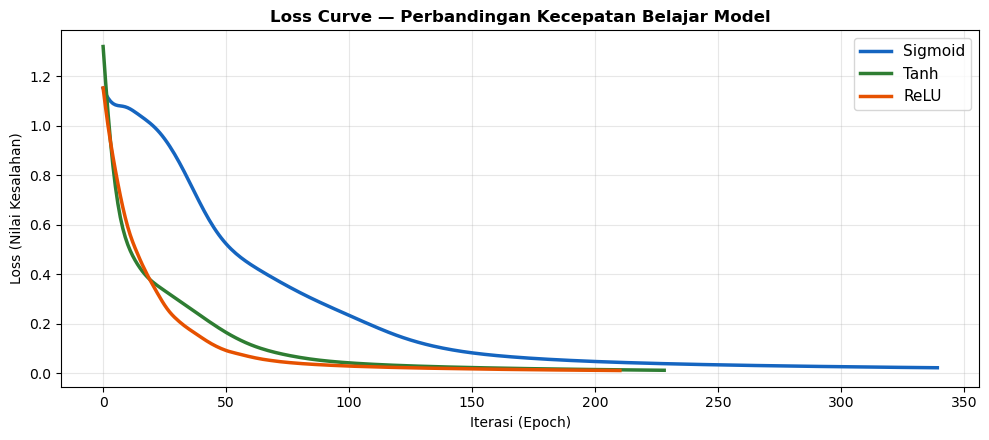

In [109]:
# =====================================================================
# LANGKAH 6: GRAPH LOSS CURVE (Kurva Belajar Model)
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 4.5))
models_dict = {
    'Sigmoid': (mlp_sigmoid, '#1565C0'),
    'Tanh'   : (mlp_tanh,    '#2E7D32'),
    'ReLU'   : (mlp_relu,    '#E65100'),
}
for name, (model, color) in models_dict.items():
    ax.plot(model.loss_curve_, label=name, color=color, lw=2.5)

ax.set_title('Loss Curve — Perbandingan Kecepatan Belajar Model', fontsize=12, fontweight='bold')
ax.set_xlabel('Iterasi (Epoch)')
ax.set_ylabel('Loss (Nilai Kesalahan)')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 10. Evaluasi Menggunakan Confusion Matrix
Penjelasan

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada masing-masing kelas sehingga performa model dapat dianalisis lebih detail.

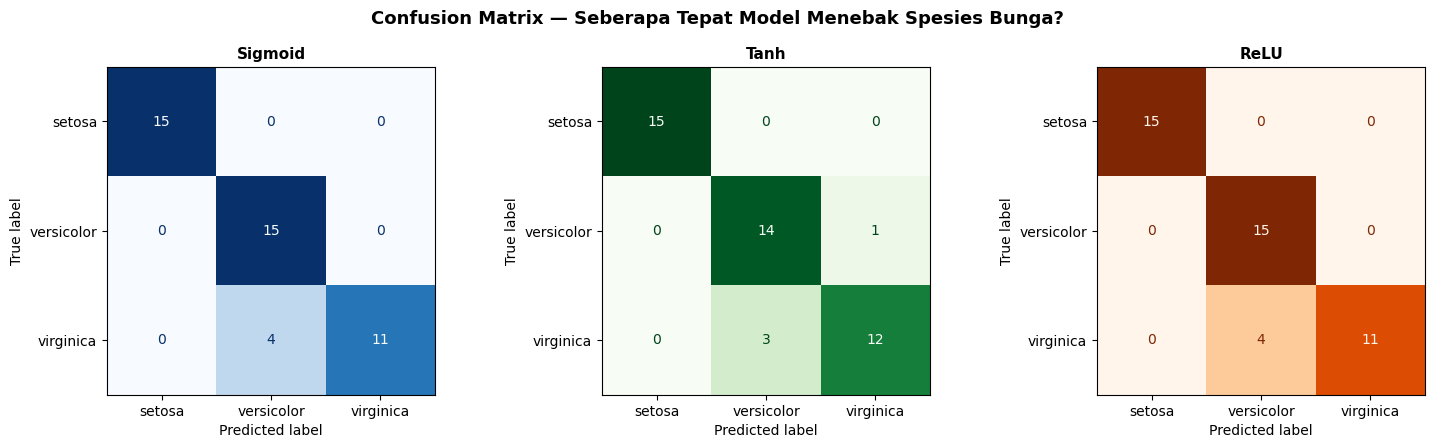

In [110]:
# =====================================================================
# LANGKAH 7: CONFUSION MATRIX (Evaluasi Detail Tebakan)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Confusion Matrix — Seberapa Tepat Model Menebak Spesies Bunga?', fontsize=13, fontweight='bold')

cm_data = [
    ('Sigmoid', y_pred_sigmoid, 'Blues'),
    ('Tanh',    y_pred_tanh,    'Greens'),
    ('ReLU',    y_pred_relu,    'Oranges'),
]

for ax, (name, y_pred, cmap) in zip(axes, cm_data):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['setosa', 'versicolor', 'virginica'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#### 11. Visualisasi Bentuk Fungsi Aktivasi
Penjelasan

Grafik ini menunjukkan bentuk matematis dari fungsi aktivasi Sigmoid, Tanh, dan ReLU sehingga perbedaan karakteristik masing-masing fungsi dapat diamati secara visual.

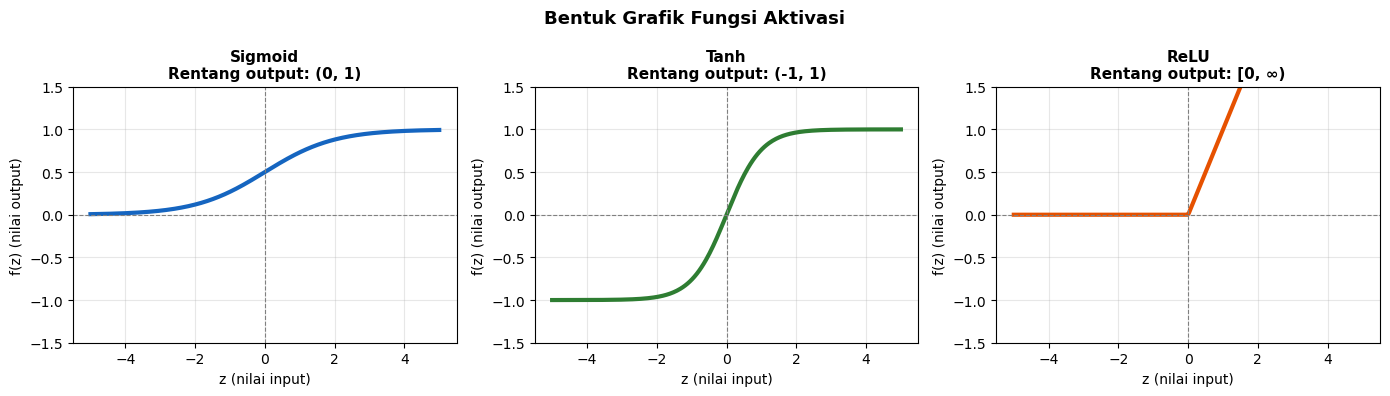

🏁 SEMUA ALUR BERHASIL DIJALANKAN DENGAN SEMPURNA!


In [111]:
# =====================================================================
# LANGKAH 8: GRAFIK MATPLOTLIB BENTUK FUNGSI AKTIVASI
# =====================================================================
z = np.linspace(-5, 5, 300)
sigmoid_vals = 1 / (1 + np.exp(-z))
tanh_vals = np.tanh(z)
relu_vals = np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Bentuk Grafik Fungsi Aktivasi', fontsize=13, fontweight='bold')
fungsi = [
    ('Sigmoid', sigmoid_vals, '#1565C0', '(0, 1)'), 
    ('Tanh', tanh_vals, '#2E7D32', '(-1, 1)'), 
    ('ReLU', relu_vals, '#E65100', '[0, ∞)')
]

for ax, (name, vals, color, rentang) in zip(axes, fungsi):
    ax.plot(z, vals, color=color, lw=3)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(f'{name}\nRentang output: {rentang}', fontsize=11, fontweight='bold')
    ax.set_xlabel('z (nilai input)')
    ax.set_ylabel('f(z) (nilai output)')
    ax.grid(alpha=0.3)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

print("🏁 SEMUA ALUR BERHASIL DIJALANKAN DENGAN SEMPURNA!")

# Kesimpulan Analisis Perbandingan Fungsi Aktivasi

Berdasarkan hasil pengujian menggunakan dataset Iris, diperoleh hasil performa sebagai berikut:

| Fungsi Aktivasi | Akurasi | Precision | Recall |  F1-Score  |
| :-------------- | :-----: | :-------: | :----: | :--------: |
| Sigmoid         |  91.11% |   92.98%  | 91.11% |   90.95%   |
| Tanh            |  91.11% |   91.55%  | 91.11% | **91.07%** |
| ReLU            |  91.11% |   92.98%  | 91.11% |   90.95%   |

## Fungsi Aktivasi Terbaik: Tanh

Berdasarkan hasil evaluasi, fungsi aktivasi **Tanh** memberikan performa terbaik pada dataset Iris. Meskipun ketiga fungsi aktivasi menghasilkan akurasi yang sama sebesar **91.11%**, fungsi Tanh memperoleh **F1-Score tertinggi yaitu 91.07%**.

### Alasan Pemilihan Tanh

1. **Memiliki F1-Score Tertinggi**
   F1-Score merupakan metrik yang menggabungkan Precision dan Recall sehingga dapat menggambarkan performa model secara lebih seimbang. Nilai F1-Score Tanh lebih tinggi dibandingkan Sigmoid dan ReLU.

2. **Output Terpusat di Nol**
   Fungsi Tanh memiliki rentang output antara -1 hingga 1, sehingga data yang dihasilkan lebih seimbang di sekitar nol. Hal ini membantu proses pembelajaran jaringan saraf menjadi lebih stabil.

3. **Proses Pembelajaran Lebih Efektif**
   Dibandingkan Sigmoid, fungsi Tanh memiliki gradien yang lebih besar pada rentang input tertentu sehingga proses pembaruan bobot (backpropagation) dapat berlangsung lebih baik.

4. **Sesuai untuk Dataset Iris**
   Dataset Iris memiliki ukuran yang relatif kecil dan pola yang cukup terstruktur. Pada kondisi ini, Tanh mampu memberikan performa yang lebih konsisten dibandingkan fungsi aktivasi lainnya.

## Kesimpulan

Berdasarkan hasil eksperimen dan analisis metrik evaluasi, dapat disimpulkan bahwa **fungsi aktivasi Tanh merupakan pilihan terbaik untuk dataset Iris pada percobaan ini** karena menghasilkan **F1-Score tertinggi (91.07%)** dengan akurasi yang tetap tinggi. Oleh karena itu, Tanh direkomendasikan sebagai fungsi aktivasi yang paling optimal untuk model klasifikasi dataset Iris yang digunakan dalam praktikum ini.

---

**Disusun oleh:** Sistra Amanda Sinaga
**NIM:** 4222301011
**Kelas:** Robotika A
